<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/explainable_deep_learning/explainable_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Deep Learning (Grad-CAM & Variants)

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Image Classification & Explainability  
**Assigned Task:** Apply GradCAM and at least two variants to a meaningful image classification problem  
**Dataset:** Custom images (at least 5 test images)  
**Deadline:** Mon Oct 6, 2025 – 11:30 AM  
**GitHub Repo:** [Assignment Folder](https://github.com/ericiortega/aipi590-xai-fall2025/tree/main/assignments/explainable_deep_learning)


## Introduction
This notebook applies GradCAM and two of its variants (GradCAM++ and Score-CAM) to a pretrained ResNet-50 model for explaining traffic sign classification.

Explainability is critical for autonomous driving because it ensures the model focuses on the relevant visual cues, such as the sign text or shape, rather than the background. This helps build trust, identify potential biases, and improve model reliability.


## Setting Up

Importing the libaries here.

In [3]:
!pip install torch torchvision timm grad-cam --quiet

import torch
import torchvision as tv
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

#Preparing images

import torch
from torchvision import transforms
from PIL import Image
import requests
from io import BytesIO

## Preprocessing & Preparing Images

In [4]:
# calling my base url from my github repo
base_url = "https://raw.githubusercontent.com/ericiortega/aipi590-xai-fall2025/main/assignments/explainable_deep_learning/images/"

filenames = [
    "stop_sign.jpg",
    "no_entry.jpeg",
    "pedestrian_crossing.jpg",
    "speed_limit.jpg",
    "yield_sign.jpeg"
]

# Resize and tensor conversion
# The following transform setup (resize and ToTensor) was generated with assistance from ChatGPT on 10/4/25 and then modified by me to fit the structure of this notebook.
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# loading images
images = []
for f in filenames:
    url = base_url + f
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    images.append(tfm(img))

batch = torch.stack(images)
print(f"Loaded {len(images)} images. Batch shape:", batch.shape)


Loaded 5 images. Batch shape: torch.Size([5, 3, 224, 224])


## Loading Pretained Model & Grad-CAM Setup

In [5]:
# Load pretrained ResNet-50
model = tv.models.resnet50(weights=tv.models.ResNet50_Weights.DEFAULT).eval()

# Target the last conv layer
target_layers = [model.layer4[-1]]

# ImageNet labels (for readable predictions)
imagenet_labels = tv.models.ResNet50_Weights.DEFAULT.meta["categories"]

## Grad-CAM visualization

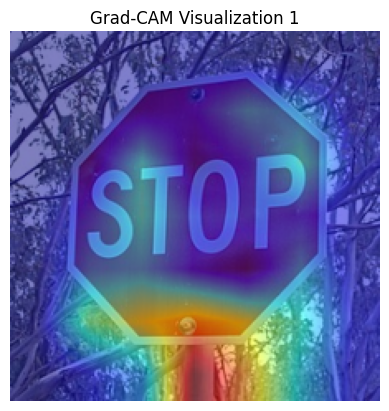

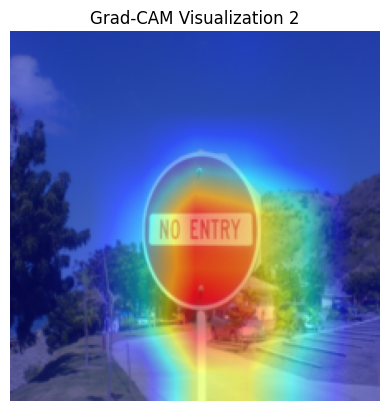

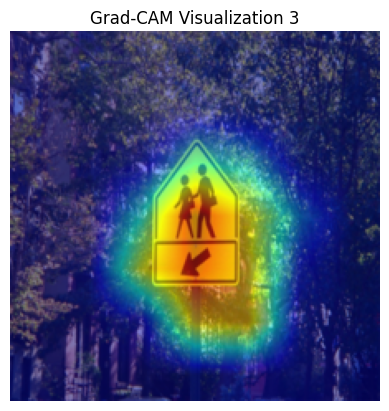

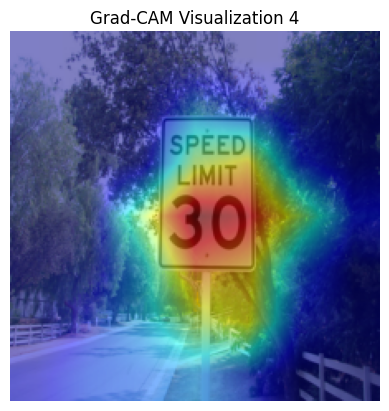

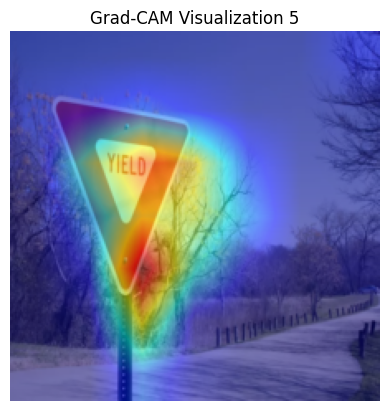

In [6]:
# Generate Grad-CAM visualizations
# Reference: Adapted from the Advanced Explainable AI notebook shared by Prof. Bent (AIPI 590, Fall 2025)
for i, img in enumerate(batch):
    input_tensor = img.unsqueeze(0)
    targets = [ClassifierOutputTarget(920)]  # example: 920 = "traffic light", adjust as needed
    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(img.permute(1, 2, 0).numpy(), grayscale_cam, use_rgb=True)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM Visualization {i+1}")
    plt.axis("off")
    plt.show()

## GradCAM++

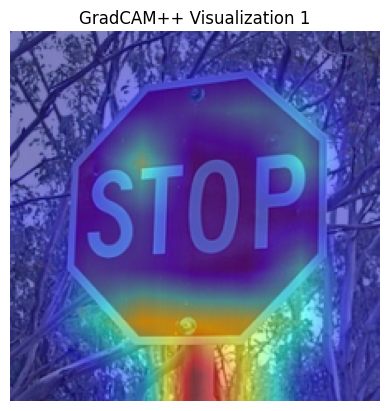

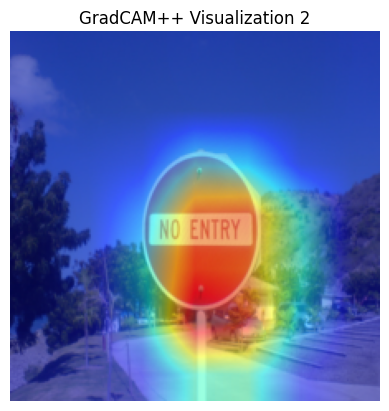

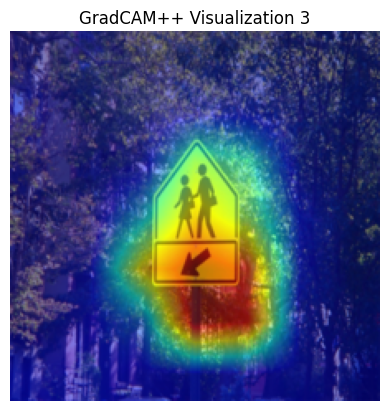

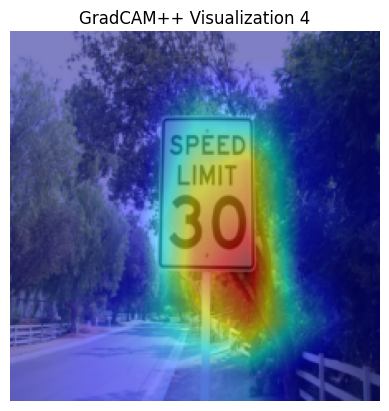

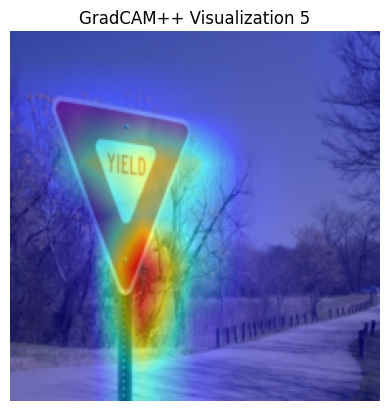

In [7]:
# GradCAM++
from pytorch_grad_cam import GradCAMPlusPlus

cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
grayscale_cams = cam(input_tensor=batch)
for i, img_tensor in enumerate(batch):
    visualization = show_cam_on_image(
        img_tensor.permute(1,2,0).numpy(),
        grayscale_cams[i],
        use_rgb=True
    )
    plt.imshow(visualization)
    plt.title(f"GradCAM++ Visualization {i+1}")
    plt.axis("off")
    plt.show()


## LayerCAM

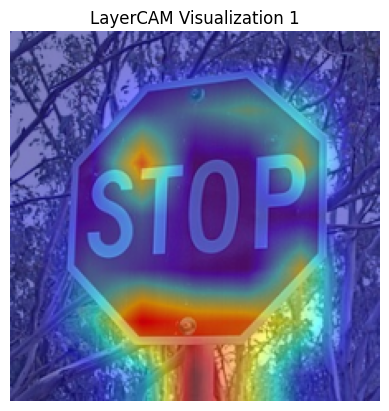

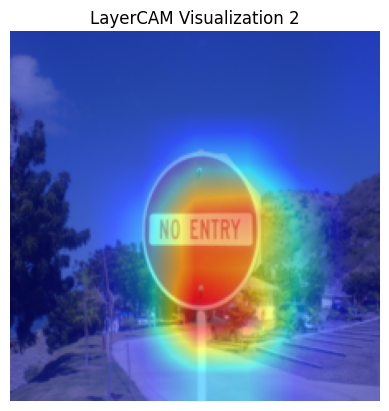

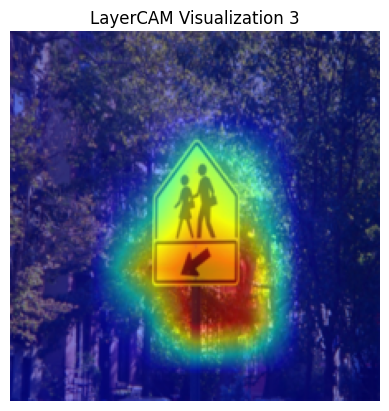

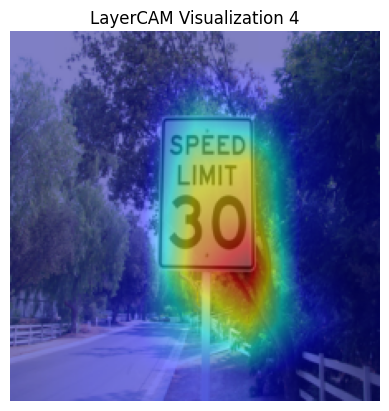

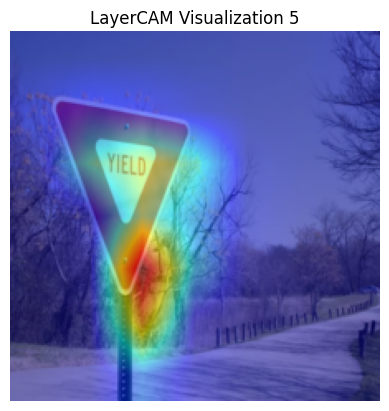

In [9]:
from pytorch_grad_cam import LayerCAM
import matplotlib.pyplot as plt

cam = LayerCAM(model=model, target_layers=target_layers)
grayscale_cams = cam(input_tensor=batch)

for i, img_t in enumerate(batch):
    vis = show_cam_on_image(img_t.permute(1,2,0).numpy(), grayscale_cams[i], use_rgb=True)
    plt.imshow(vis); plt.title(f"LayerCAM Visualization {i+1}"); plt.axis("off"); plt.show()
